In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 2070 SUPER


In [3]:
import gdown
import zipfile
import os

os.makedirs("../data", exist_ok=True)

# COD10K-v3
url = "https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5"
output = "../data/COD10K.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("../data/")

print("Done")

Downloading...
From (original): https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5
From (redirected): https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5&confirm=t&uuid=233da23b-6b63-4809-859c-d2ea7c1e4008
To: c:\Projects\camouflage-detection\data\COD10K.zip
100%|██████████| 2.42G/2.42G [03:59<00:00, 10.1MB/s]


Done


In [8]:
# Посмотрим на имена файлов в обеих папках
img_files = sorted(os.listdir(TRAIN_IMG))[:5]
mask_files = sorted(os.listdir(TRAIN_MASK))[:5]

print("Images:", img_files)
print("Masks: ", mask_files)

Images: ['COD10K-CAM-1-Aquatic-1-BatFish-1.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-3.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-7.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-8.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-9.jpg']
Masks:  ['COD10K-CAM-1-Aquatic-1-BatFish-1.png', 'COD10K-CAM-1-Aquatic-1-BatFish-3.png', 'COD10K-CAM-1-Aquatic-1-BatFish-7.png', 'COD10K-CAM-1-Aquatic-1-BatFish-8.png', 'COD10K-CAM-1-Aquatic-1-BatFish-9.png']


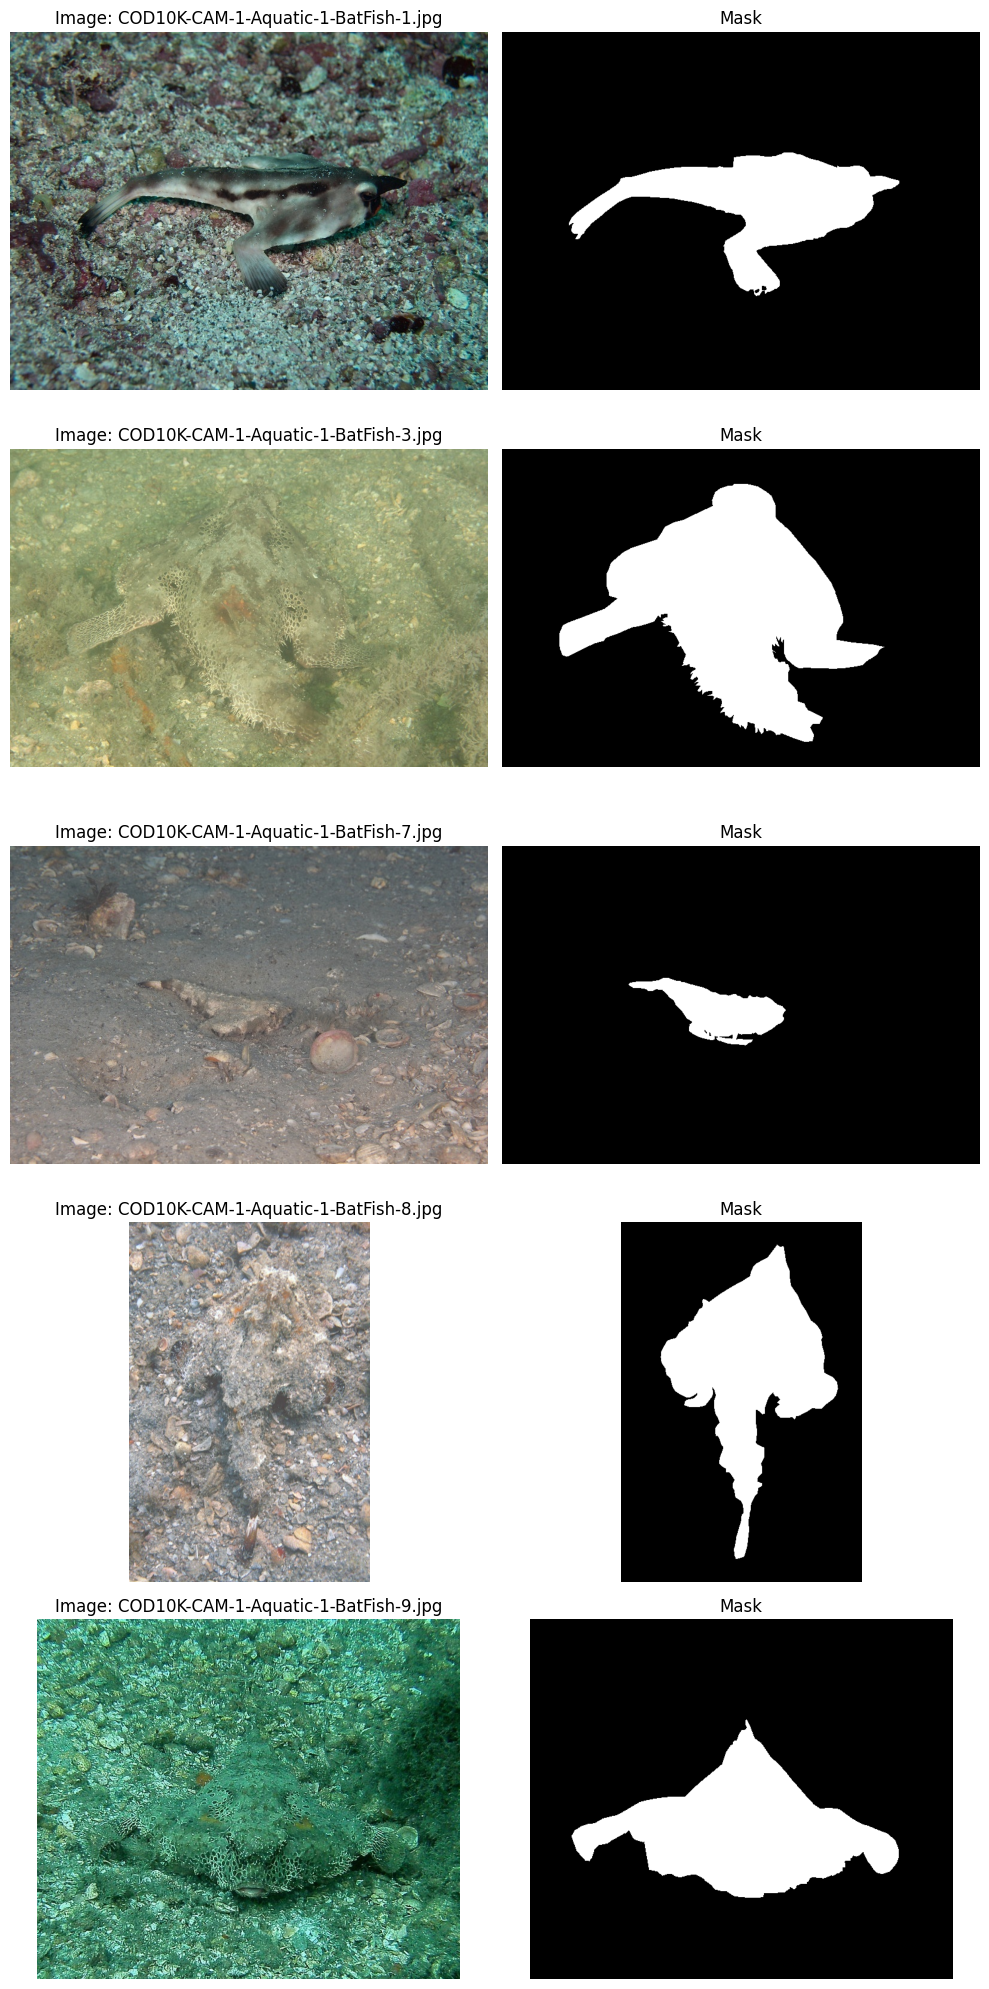

In [9]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Пути
TRAIN_IMG = "../data/COD10K-v3/Train/Image"
TRAIN_MASK = "../data/COD10K-v3/Train/GT_Object"

# Берём первые 5 файлов
images = sorted(os.listdir(TRAIN_IMG))[:5]

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, fname in enumerate(images):
    # Загружаем изображение
    img = cv2.imread(os.path.join(TRAIN_IMG, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Загружаем маску (то же имя файла)
    mask_name = os.path.splitext(fname)[0] + ".png"
    mask_path = os.path.join(TRAIN_MASK, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image: {fname}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CODDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=352):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.images = sorted(os.listdir(img_dir))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = cv2.imread(os.path.join(self.img_dir, self.images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        mask_name = os.path.splitext(self.images[idx])[0] + ".png"
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).unsqueeze(0).float() / 255.0
        
        return img, mask
    
train_dataset = CODDataset(TRAIN_IMG, TRAIN_MASK)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print(f"изображений в датасете: {len(train_dataset)}")
print(f"Батчей в DataLoader: {len(train_loader)}")

        

изображений в датасете: 6000
Батчей в DataLoader: 750


In [11]:
# Берём один батч и смотрим на формы тензоров
imgs, masks = next(iter(train_loader))

print(f"Форма батча изображений: {imgs.shape}")
print(f"Форма батча масок: {masks.shape}")
print(f"Мин/макс пикселей изображения: {imgs.min():.2f} / {imgs.max():.2f}")
print(f"Мин/макс пикселей маски: {masks.min():.2f} / {masks.max():.2f}")

Форма батча изображений: torch.Size([8, 3, 352, 352])
Форма батча масок: torch.Size([8, 1, 352, 352])
Мин/макс пикселей изображения: 0.00 / 1.00
Мин/макс пикселей маски: 0.00 / 1.00


In [35]:
import segmentation_models_pytorch as smp
import torch.optim as optim
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).cuda()

criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [36]:
# Ячейка 2 — цикл обучения (без изменений)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for imgs, masks in train_loader:
        imgs = imgs.cuda()
        masks = masks.cuda()
        
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

Epoch 1/10 | Loss: 0.7376
Epoch 2/10 | Loss: 0.5542
Epoch 3/10 | Loss: 0.4837
Epoch 4/10 | Loss: 0.4445
Epoch 5/10 | Loss: 0.4144


KeyboardInterrupt: 

In [17]:
import os
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/unet_cod10k.pth")
print("Модель сохранена")

Модель сохранена


In [37]:
model.load_state_dict(torch.load("../models/unet_cod10k.pth"))
print("Веса загружены")

Веса загружены


C:\Users\user\AppData\Local\Temp\ipykernel_10196\1511972150.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/unet_cod10k.pth")

In [25]:
test_dataset = CODDataset(
    "../data/COD10K-v3/Test/Image",
    "../data/COD10K-v3/Test/GT_Object"
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Тестовых изображений: {len(test_dataset)}")

Тестовых изображений: 4000


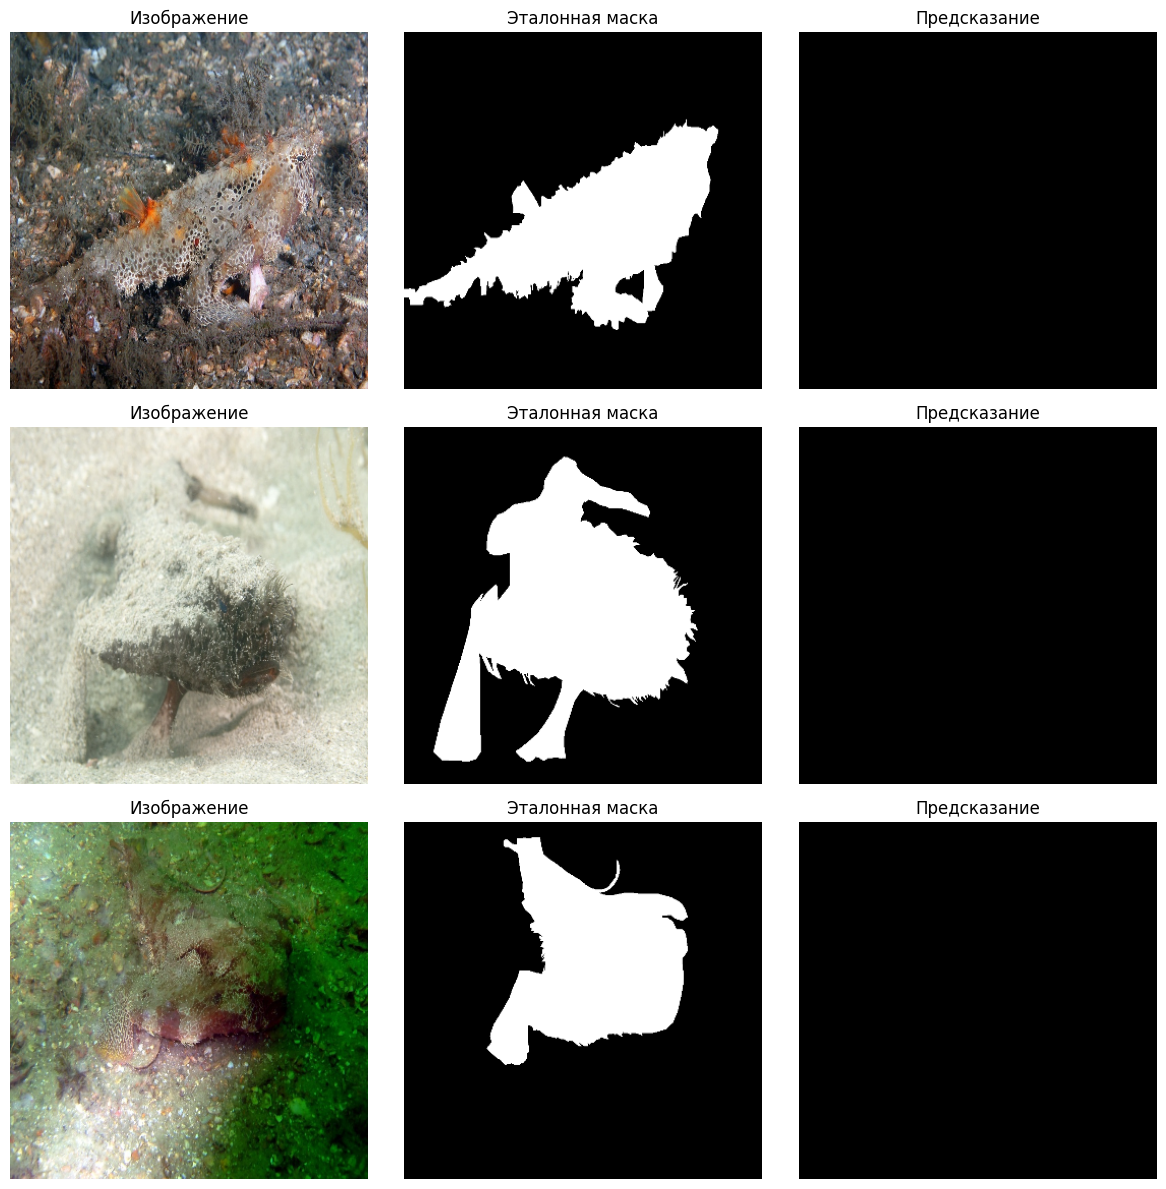

In [ ]:
model.eval()

imgs, masks = next(iter(test_loader))
imgs = imgs.cuda()

with torch.no_grad():
    preds = model(imgs)

# Переводим обратно на CPU для визуализации
imgs = imgs.cpu()
preds = preds.cpu()

# Бинаризуем предсказания — порог 0.5
preds_binary = (torch.sigmoid(preds) > 0.1).float()

# Визуализируем первые 3 примера
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    img = imgs[i].permute(1, 2, 0).numpy()
    mask = masks[i].squeeze().numpy()
    pred = preds_binary[i].squeeze().numpy()
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Изображение")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Эталонная маска")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(pred, cmap="gray")
    axes[i, 2].set_title("Предсказание")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [40]:
preds_sigmoid = torch.sigmoid(preds)
print(f"После sigmoid - мин: {preds_sigmoid.min():.4f}")
print(f"После sigmoid - макс: {preds_sigmoid.max():.4f}")
print(f"После sigmoid - среднее: {preds_sigmoid.mean():.4f}")

После sigmoid - мин: 0.0000
После sigmoid - макс: 0.1804
После sigmoid - среднее: 0.0002
